# Spatial single-cell type annotation

This tutorial demonstrates the HBC1 cell-type annotation workflow. PhenoMap first annotates generated spatial single-cell expression using reference-derived marker genes. Three supervised transfer methods, CellTypist, Tangram and Ingest, are then combined into an ensemble label that is used as the reference label for downstream evaluation.

In [1]:
from pathlib import Path
import sys
import os
import ast
import subprocess

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.metrics import f1_score
from scipy.stats import pearsonr


def find_repo_root():
    current = Path.cwd().resolve()
    for path in (current, *current.parents):
        if (path / "README.md").exists() and (path / "step1").exists():
            return path
    raise RuntimeError(
        "Please run this notebook from inside the PhenoMap repository."
    )


REPO_ROOT = find_repo_root()
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from step1.utils.plotting import (
    plot_expression_annotation_heatmaps,
    plot_major_class_metric_bars,
    plot_spatial_cell_type_maps,
    set_plot_style,
)

set_plot_style()

DATA_ROOT = Path(os.environ["PHENOMAP_DATA"]).expanduser().resolve()
HBC1_DIR = DATA_ROOT / "HBC1"
CELL_TYPE_DIR = HBC1_DIR / "cell_type"
TUTORIAL_DIR = REPO_ROOT / "outputs" / "02_spatial_cell_type_annotation"
TUTORIAL_DIR.mkdir(parents=True, exist_ok=True)

RUN_HEAVY_STEPS = False

EXPR_PRED_PATH = HBC1_DIR / "pre_ours.csv"
EXPR_TRUE_PATH = HBC1_DIR / "cell_gene_matrix_filtered.csv"
FEATURE_H5_PATH = HBC1_DIR / "histology_cell_multifeatures.h5"
OURS_LABEL_PATH = CELL_TYPE_DIR / "anno_oursgene_318.csv"
GT_LABEL_PATH = CELL_TYPE_DIR / "GT_三合一.csv"

CELL_TYPES = [
    "Cancer_epithelial", "Stromal", "T_cells", "Myeloid",
    "Normal_epithelial", "Endothelial", "B_cells", "Unknown",
]
CELL_COLORS = {
    "Cancer_epithelial": "#DE5253",
    "Stromal": "#989898",
    "T_cells": "#56B356",
    "Myeloid": "#45CBD8",
    "Normal_epithelial": "#E892CE",
    "Endothelial": "#FF983E",
    "B_cells": "#4C92C3",
    "Unknown": "#333333",
}

print("Repository and HBC1 inputs located.")
print(f"Tutorial output directory: {TUTORIAL_DIR.relative_to(REPO_ROOT)}")
print(f"Run heavy steps:  {RUN_HEAVY_STEPS}")


Repository and HBC1 inputs located.
Tutorial output directory: outputs/02_spatial_cell_type_annotation
Run heavy steps:  False


## 1. Derive marker genes from the reference atlas

Marker genes are selected from the Wu et al. breast cancer single-cell reference and restricted to genes detected in the HBC1 spatial single-cell matrix. The runnable marker-selection entry point is `cell_type/筛选marker.py`; the annotation script stores the resulting marker dictionary used by PhenoMap.

In [2]:
cmd_marker = ["python", "cell_type/筛选marker.py"]
print("$", " ".join(cmd_marker))
if RUN_HEAVY_STEPS:
    subprocess.run(cmd_marker, cwd=REPO_ROOT, check=True)
else:
    print("Skipped. Set RUN_HEAVY_STEPS=True to regenerate the marker list from the reference table.")

source = (REPO_ROOT / "cell_type" / "类型注释.py").read_text(encoding="utf-8")
tree = ast.parse(source)
marker_dict = None
for node in ast.walk(tree):
    if isinstance(node, ast.Assign):
        for target in node.targets:
            if isinstance(target, ast.Name) and target.id == "marker_dict":
                marker_dict = ast.literal_eval(node.value)
if marker_dict is None:
    raise RuntimeError("marker_dict was not found in cell_type/类型注释.py")

marker_summary = pd.DataFrame({
    "cell_type": list(marker_dict),
    "n_markers": [len(v) for v in marker_dict.values()],
    "markers": [", ".join(v) for v in marker_dict.values()],
})
marker_summary.style.hide(axis="index")

$ python cell_type/筛选marker.py
Skipped. Set RUN_HEAVY_STEPS=True to regenerate the marker list from the reference table.


cell_type,n_markers,markers
B_cells,6,"MZB1, MS4A1, CD83, BANK1, ITM2C, SEC11C"
Cancer_epithelial,10,"ELF3, S100A14, CLDN4, KRT7, KRT8, AGR3, ANKRD30A, EPCAM, CCND1, CD9"
Endothelial,10,"RAMP2, VWF, AQP1, PECAM1, CLEC14A, CD93, TCF4, PDK4, STC1, MMRN2"
Myeloid,9,"LYZ, C1QA, C1QC, TYROBP, APOC1, FCER1G, AIF1, CD68, CD14"
Normal_epithelial,8,"KRT14, KRT15, PTN, TACSTD2, KRT5, SFRP1, DST, ACTG2"
Stromal,10,"LUM, ACTA2, POSTN, CCDC80, SFRP4, PTGDS, MMP2, FBLN1, CXCL12, MYH11"
T_cells,10,"CCL5, IL7R, CD3E, CXCR4, CD69, CD3D, GZMA, PTPRC, DUSP2, TRAC"


## 2. Annotate PhenoMap-generated single-cell expression

The PhenoMap annotation step scores each cell against the reference-derived marker sets and assigns the cell type with the highest marker score. The script entry point is `cell_type/类型注释.py`, now configured for HBC1 and `pre_ours.csv`.

In [3]:
cmd_ours = ["python", "cell_type/类型注释.py"]
print("$", " ".join(cmd_ours))
if RUN_HEAVY_STEPS:
    subprocess.run(cmd_ours, cwd=REPO_ROOT, check=True)
else:
    print("Skipped. Set RUN_HEAVY_STEPS=True to rerun PhenoMap marker-based annotation.")

ours = pd.read_csv(OURS_LABEL_PATH, index_col=0)
ours.index = ours.index.astype(str)
print(f"PhenoMap annotation: {OURS_LABEL_PATH.name}")
print(f"Annotated cells: {len(ours):,}")
cell_type_counts = (
    ours["cell_type"].value_counts()
    .reindex(CELL_TYPES).fillna(0).astype(int)
    .rename_axis("cell_type").reset_index(name="n_cells")
)
cell_type_counts.style.hide(axis="index")

$ python cell_type/类型注释.py
Skipped. Set RUN_HEAVY_STEPS=True to rerun PhenoMap marker-based annotation.


PhenoMap annotation: anno_oursgene_318.csv
Annotated cells: 126,438


cell_type,n_cells
Cancer_epithelial,47080
Stromal,25241
T_cells,22918
Myeloid,9630
Normal_epithelial,8348
Endothelial,10768
B_cells,1924
Unknown,529


## 3. Build the ensemble ground-truth label

CellTypist, Tangram and Ingest independently transfer labels from the reference atlas to the measured HBC1 single-cell expression matrix. `生成最终label.py` combines the three outputs into a hard ensemble label.

In [4]:
supervised_cmds = [
    ["python", "cell_type/celltypist+hbc.py"],
    ["python", "cell_type/Tangram+hbc.py"],
    ["python", "cell_type/ingest+hbc.py"],
    ["python", "cell_type/生成最终label.py"],
]
for cmd in supervised_cmds:
    print("$", " ".join(cmd))
    if RUN_HEAVY_STEPS:
        subprocess.run(cmd, cwd=REPO_ROOT, check=True)
    else:
        print("  skipped")
if not RUN_HEAVY_STEPS:
    print("Set RUN_HEAVY_STEPS=True to rebuild CellTypist, Tangram, Ingest and the ensemble label.")

gt = pd.read_csv(GT_LABEL_PATH, index_col=0)
gt.index = gt.index.astype(str)
print(f"Ensemble ground truth: {GT_LABEL_PATH.name}")
print(f"Ground-truth cells:    {len(gt):,}")

decision_counts = (
    gt["Decision_Level"].value_counts()
    .rename_axis("decision_level").reset_index(name="n_cells")
)
decision_counts.style.hide(axis="index")

$ python cell_type/celltypist+hbc.py
  skipped
$ python cell_type/Tangram+hbc.py
  skipped
$ python cell_type/ingest+hbc.py
  skipped
$ python cell_type/生成最终label.py
  skipped
Set RUN_HEAVY_STEPS=True to rebuild CellTypist, Tangram, Ingest and the ensemble label.
Ensemble ground truth: GT_三合一.csv
Ground-truth cells:    125,766


decision_level,n_cells
1_Consensus,80693
2_Majority_CT_IG,26317
2_Majority_TG_IG,6561
2_Majority_TG_CT,6111
3_LowProb_IG_Fallback,2748
3_HighProb_TG_Wins,2350
3_HighProb_CT_Wins,986


## 4. Align labels and inspect cell-type composition

All downstream comparisons use the intersection of PhenoMap-annotated cells and ensemble-labelled cells.

In [5]:
common_cells = ours.index.intersection(gt.index)
ours_aligned = ours.loc[common_cells].copy()
gt_aligned = gt.loc[common_cells].copy()

label_table = pd.DataFrame({
    "PhenoMap": ours_aligned["cell_type"].value_counts(),
    "Ground truth": gt_aligned["Ensemble_Label"].value_counts(),
}).reindex(CELL_TYPES).fillna(0).astype(int)
prop_table = label_table.div(label_table.sum(axis=0), axis=1)

print(f"Aligned cells: {len(common_cells):,}")
composition_summary = prop_table.rename_axis("cell_type").reset_index()
composition_summary.round(4).style.hide(axis="index")

Aligned cells: 125,766


cell_type,PhenoMap,Ground truth
Cancer_epithelial,0.373500,0.436700
Stromal,0.200400,0.177200
T_cells,0.181100,0.187600
Myeloid,0.076400,0.090600
Normal_epithelial,0.066300,0.032500
Endothelial,0.085200,0.052000
B_cells,0.014800,0.023400
Unknown,0.002400,0.000000


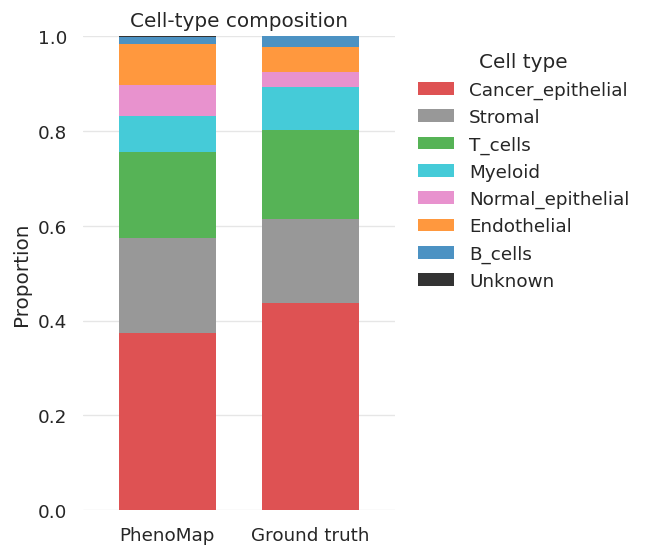

Saved: hbc1_composition_phenomap_vs_groundtruth.png


In [6]:
fig, ax = plt.subplots(figsize=(5.6, 4.8))
prop_table.T.plot(
    kind="bar", stacked=True, color=[CELL_COLORS[c] for c in CELL_TYPES],
    width=0.68, edgecolor="none", ax=ax,
)
ax.set(xlabel="", ylabel="Proportion", title="Cell-type composition")
ax.set_ylim(0, 1)
ax.yaxis.grid(True, color="#e6e6e6", linewidth=0.8)
for spine in ax.spines.values():
    spine.set_visible(False)
ax.legend(title="Cell type", bbox_to_anchor=(1.02, 1), loc="upper left", frameon=False)
plt.setp(ax.get_xticklabels(), rotation=0)
plt.tight_layout()
composition_path = TUTORIAL_DIR / "hbc1_composition_phenomap_vs_groundtruth.png"
fig.savefig(composition_path, bbox_inches="tight")
plt.show()
print(f"Saved: {composition_path.name}")

## 5. Visualize spatial annotations

For a lightweight tutorial view, cell centroids are read from the Step 1 feature HDF5 file and colored by label. The full H&E-overlay rendering can be regenerated with `cell_type/细胞类型可视化.py`.

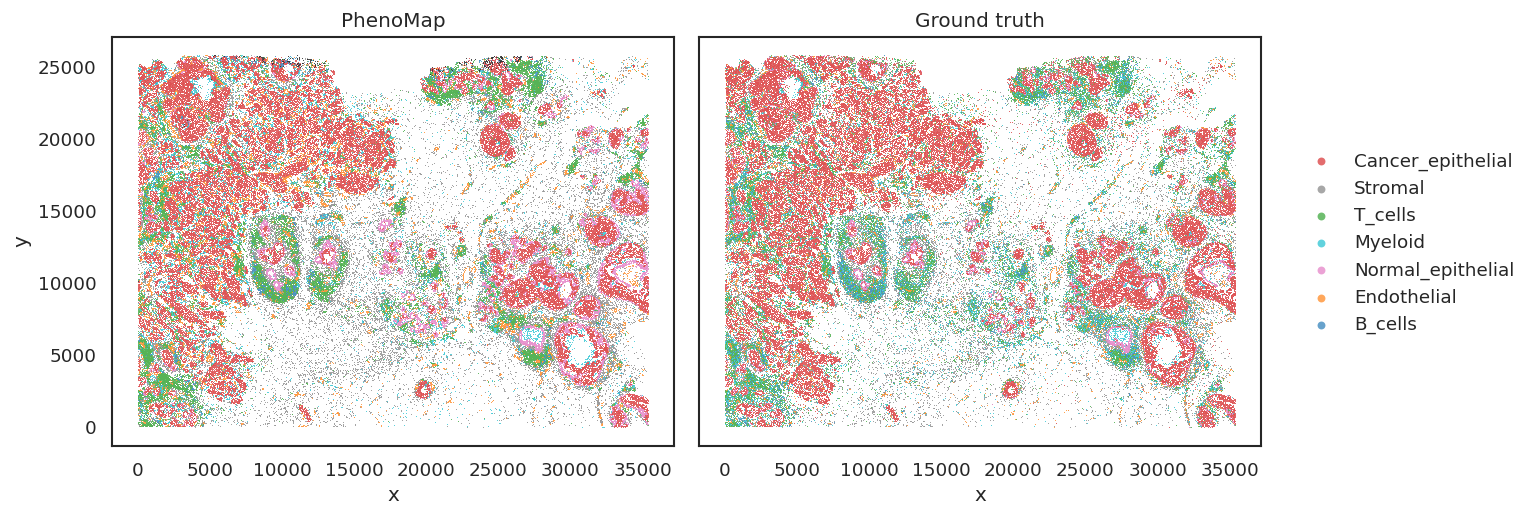

Cells shown per panel: 125,766
Saved: hbc1_spatial_cell_type_maps.png


In [7]:
metadata = pd.read_hdf(FEATURE_H5_PATH, key="metadata")
metadata.index = metadata.index.astype(str)
meta_common = metadata.loc[metadata.index.intersection(common_cells)].copy()

map_path = plot_spatial_cell_type_maps(
    metadata=meta_common,
    label_series_by_panel={
        "PhenoMap": ours_aligned.loc[meta_common.index, "cell_type"],
        "Ground truth": gt_aligned.loc[meta_common.index, "Ensemble_Label"],
    },
    cell_types=CELL_TYPES,
    cell_colors=CELL_COLORS,
    output_path=TUTORIAL_DIR / "hbc1_spatial_cell_type_maps.png",
)
print(f"Cells shown per panel: {len(meta_common):,}")
print(f"Saved: {map_path.name}")

## 6. Expression heatmaps stratified by annotated cell type

The heatmaps below show marker-gene expression across cells ordered by their annotated cell type. The ground-truth panel uses the measured Xenium expression matrix and labels produced from Xenium genes; the PhenoMap panel uses the generated expression matrix and labels produced from PhenoMap-predicted genes.

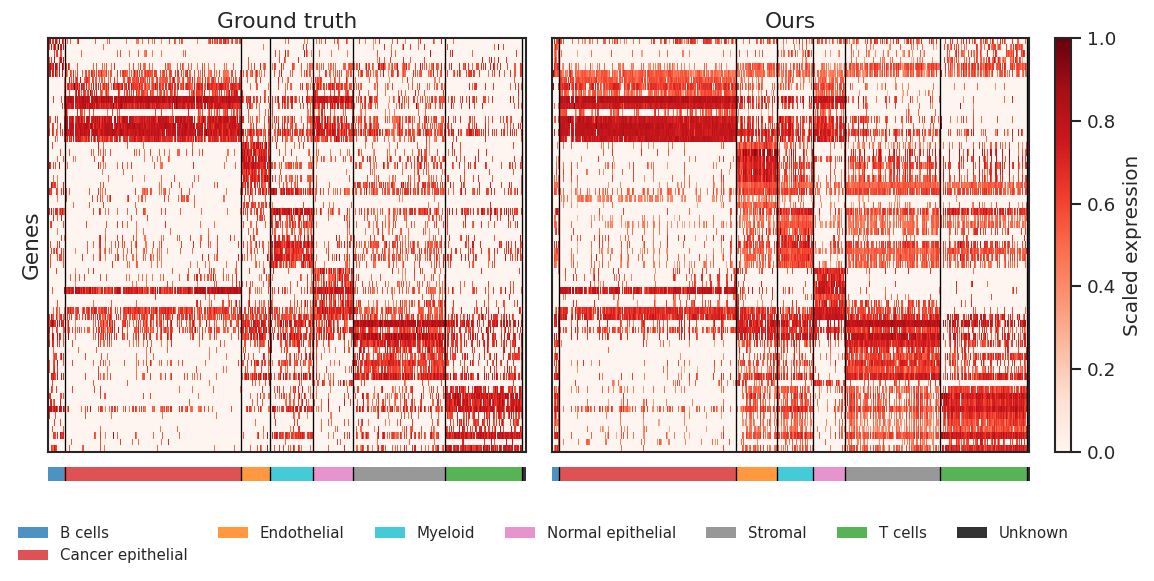

Marker genes shown: 63
Ground-truth cells: 126,438
PhenoMap cells:         126,438
Saved: hbc1_expression_annotation_heatmaps.png


In [8]:
marker_genes = list(dict.fromkeys(gene for genes in marker_dict.values() for gene in genes))

def read_marker_expression(path):
    columns = pd.read_csv(path, nrows=0).columns.tolist()
    available = [gene for gene in marker_genes if gene in columns]
    return pd.read_csv(path, index_col=0, usecols=[columns[0], *available])

true_expression = read_marker_expression(HBC1_DIR / "cell_gene_matrix_filtered.csv")
pred_expression = read_marker_expression(HBC1_DIR / "pre_ours.csv")
true_annotation = pd.read_csv(CELL_TYPE_DIR / "anno_truegene_318.csv", index_col=0)
pred_annotation = pd.read_csv(CELL_TYPE_DIR / "anno_oursgene_318.csv", index_col=0)
for table in [true_expression, pred_expression, true_annotation, pred_annotation]:
    table.index = table.index.astype(str)

heatmap_info = plot_expression_annotation_heatmaps(
    true_expr=true_expression,
    pred_expr=pred_expression,
    true_annotation=true_annotation,
    pred_annotation=pred_annotation,
    marker_dict=marker_dict,
    cell_colors=CELL_COLORS,
    output_path=TUTORIAL_DIR / "hbc1_expression_annotation_heatmaps.png",
)
print(f"Marker genes shown: {len(heatmap_info['marker_genes'])}")
print(f"Ground-truth cells: {heatmap_info['ground_truth_cells']:,}")
predicted_cell_key = next(
    key for key in heatmap_info if key.endswith("_cells") and key != "ground_truth_cells"
)
print(f"PhenoMap cells:         {heatmap_info[predicted_cell_key]:,}")
print(f"Saved: {Path(heatmap_info['path']).name}")

## 7. Quantify agreement with the ensemble label

Agreement with the ensemble label is summarized by major cell class. F1-score is computed from hard major-class labels, and Spatial PCC measures the correlation between each ensemble one-hot class map and the PhenoMap marker-score probability for the same class.

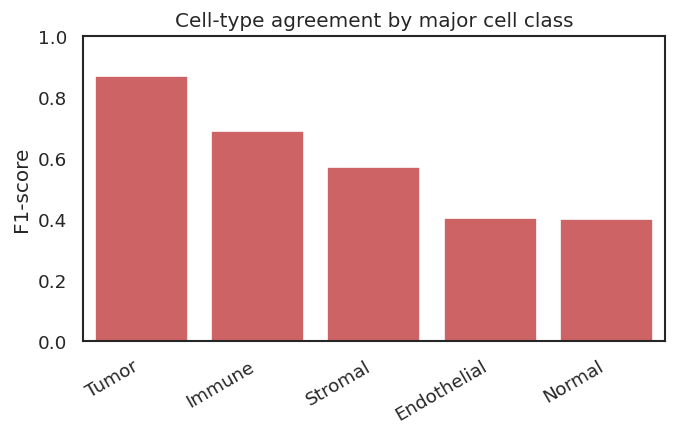

Saved: hbc1_major_class_f1.png


major_class,f1_score
Tumor,0.869100
Immune,0.687900
Stromal,0.572700
Endothelial,0.403400
Normal,0.401300


In [9]:
MERGE_MAP = {
    "Cancer_epithelial": "Tumor",
    "T_cells": "Immune",
    "B_cells": "Immune",
    "Myeloid": "Immune",
    "Stromal": "Stromal",
    "Endothelial": "Endothelial",
    "Normal_epithelial": "Normal",
}
MAJOR_CLASSES = ["Tumor", "Immune", "Stromal", "Endothelial", "Normal"]
SEVEN_CLASSES = [c for c in CELL_TYPES if c != "Unknown"]

y_true_7 = gt_aligned["Ensemble_Label"]
y_pred_7 = ours_aligned["cell_type"]
y_true_major = y_true_7.map(MERGE_MAP)
y_pred_major = y_pred_7.map(MERGE_MAP)
valid_major = y_true_major.isin(MAJOR_CLASSES) & y_pred_major.isin(MAJOR_CLASSES)

f1_rows = []
for major in MAJOR_CLASSES:
    f1 = f1_score(
        (y_true_major[valid_major] == major).astype(int),
        (y_pred_major[valid_major] == major).astype(int),
        zero_division=0,
    )
    f1_rows.append({"major_class": major, "f1_score": f1})
major_f1 = pd.DataFrame(f1_rows)

f1_path = plot_major_class_metric_bars(
    metric_df=major_f1,
    metric_col="f1_score",
    ylabel="F1-score",
    title="Cell-type agreement by major cell class",
    output_path=TUTORIAL_DIR / "hbc1_major_class_f1.png",
    ylim=(0, 1.0),
)
print(f"Saved: {f1_path.name}")
major_f1.round(4).style.hide(axis="index")

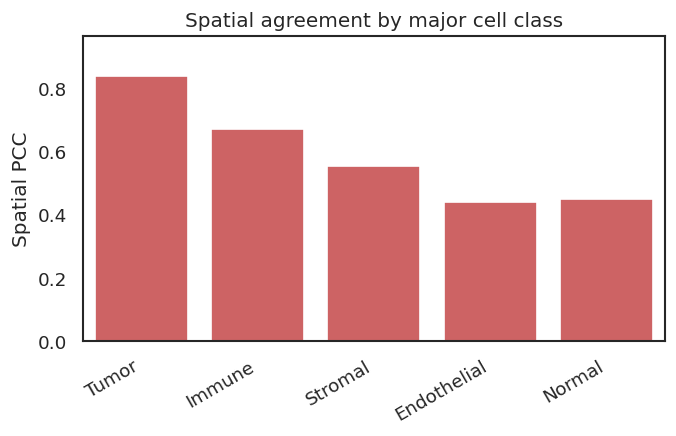

Saved: hbc1_spatial_pcc.png


major_class,spatial_pcc
Tumor,0.837100
Immune,0.670200
Stromal,0.552600
Endothelial,0.440800
Normal,0.449400


In [10]:
def softmax_scores(df, cols):
    scores = df[cols].astype(float)
    shifted = scores.sub(scores.max(axis=1), axis=0)
    exp_scores = np.exp(shifted)
    return exp_scores.div(exp_scores.sum(axis=1), axis=0).fillna(0)

score_cols_all = [f"{c}_score" for c in SEVEN_CLASSES if f"{c}_score" in ours_aligned.columns]
prob = softmax_scores(ours_aligned, score_cols_all)
prob.columns = [c.replace("_score", "") for c in prob.columns]

major_prob = pd.DataFrame(index=prob.index)
for major in MAJOR_CLASSES:
    source_classes = [k for k, v in MERGE_MAP.items() if v == major and k in prob.columns]
    major_prob[major] = prob[source_classes].sum(axis=1)

spatial_rows = []
for major in MAJOR_CLASSES:
    y_binary = (y_true_major.loc[major_prob.index] == major).astype(float)
    if y_binary.sum() == 0 or major_prob[major].std() == 0:
        pcc = np.nan
    else:
        pcc, _ = pearsonr(y_binary.values, major_prob[major].values)
    spatial_rows.append({"major_class": major, "spatial_pcc": pcc})
spatial_pcc = pd.DataFrame(spatial_rows)

pcc_path = plot_major_class_metric_bars(
    metric_df=spatial_pcc,
    metric_col="spatial_pcc",
    ylabel="Spatial PCC",
    title="Spatial agreement by major cell class",
    output_path=TUTORIAL_DIR / "hbc1_spatial_pcc.png",
    ylim=(0, max(0.05, spatial_pcc["spatial_pcc"].max() * 1.15)),
)
print(f"Saved: {pcc_path.name}")
spatial_pcc.round(4).style.hide(axis="index")